In [16]:
#Will keep everything same as the original code , and will only add batch normalization to the code

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision.transforms import v2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True),
    v2.Normalize((0.4914, 0.4822, 0.4465),(0.2470, 0.2435, 0.2616))
])

train_dataset = torchvision.datasets.CIFAR10(root = "./data", train = True, download = True, transform = transform )
test_dataset = torchvision.datasets.CIFAR10(root = "./data", train = False, download = True, transform = transform)

train_loader = DataLoader(train_dataset, batch_size = 128, shuffle = True, pin_memory = torch.cuda.is_available())
test_loader = DataLoader(test_dataset, shuffle = False , batch_size = 128, pin_memory = torch.cuda.is_available())

classes = ('plane', 'car', 'bird', 'cat','deer', 'dog', 'frog', 'horse', 'ship', 'truck')


batch_X, batch_y = next(iter(train_loader))
print(batch_X.shape)
print(batch_X.min(), batch_X.max())
print(batch_X.dtype)


torch.Size([128, 3, 32, 32])
tensor(-1.9895) tensor(2.1265)
torch.float32


In [12]:
from torch.nn.modules.linear import Linear
from torch.nn.modules.flatten import Flatten
class Convolution(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Conv2d(3,32,3,1,1),
        nn.BatchNorm2d(32),
        nn.ReLU(),

        nn.Conv2d(32,64,3,1,1),
        nn.BatchNorm2d(64),
        nn.ReLU(),

        nn.MaxPool2d(2,2),

        nn.Conv2d(64,128,3,1,1),
        nn.BatchNorm2d(128),
        nn.ReLU(),

        nn.Conv2d(128,128,3,1,1),
        nn.BatchNorm2d(128),
        nn.ReLU(),

        nn.MaxPool2d(2,2),

        nn.Flatten(),

        nn.Linear(128*8*8, 512),
       
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512,10)
    )

  def forward(self,X):
    return self.model(X)


model = Convolution()
model = model.to(device)

print(model)



Convolution(
  (model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Flatten(start_

In [13]:
lr = 0.01
epochs = 5
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr = lr)

Epoch : [1 / 5] : 3.1998303376
Epoch : [2 / 5] : 2.0667266904
Epoch : [3 / 5] : 1.9404682799
Epoch : [4 / 5] : 1.8264050292
Epoch : [5 / 5] : 1.6979489650


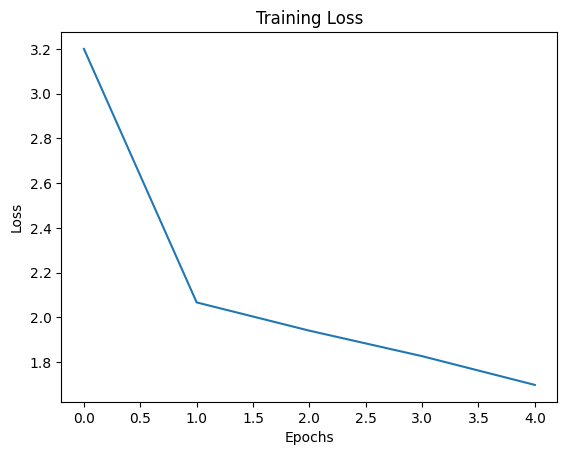

In [14]:
train_losses = []
for epoch in range(epochs):
  model.train()
  total_epoch_loss = 0;
  for batch_X, batch_y in train_loader:
    batch_X = batch_X.to(device)
    batch_y = batch_y.to(device)

    y_pred = model(batch_X)
    loss = loss_fn(y_pred, batch_y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_epoch_loss +=loss.item()
  average_epoch_loss = total_epoch_loss/len(train_loader)
  train_losses.append(average_epoch_loss)
  print(f"Epoch : [{epoch + 1 } / {epochs}] : {average_epoch_loss:.10f}")
plt.plot([t1 for t1 in train_losses])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()


In [15]:
correct = 0
total_labels = len(test_dataset)
model.eval()

with torch.no_grad():
  for batch_X, batch_y in test_loader:
    batch_correct_preds = 0
    batch_X = batch_X.to(device)
    batch_y  = batch_y.to(device)
    y_pred = model(batch_X)
    predicted_labels = torch.argmax(y_pred, dim =1)
    batch_correct_preds += (predicted_labels == batch_y).sum().item()
    correct += batch_correct_preds

print(correct)
acc = correct/ total_labels
print(f"The accuracy of the currrent model is : {acc*100:.10f}")

4197
The accuracy of the currrent model is : 41.9700000000
